# 1. Data 경로 확인 및 불러오기

In [1]:
# 1. 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import librosa
import IPython.display as ipd
from tqdm import tqdm # 진행 상황을 보기 위한 라이브러리


# 2. 데이터 경로 설정 (Kaggle 전용 경로)
# 알려주신 경로로 정확히 타겟팅합니다.
root = '/kaggle/input/datasets/joserzapata/free-spoken-digit-dataset-fsdd'
# 3. 파일 불러오기 및 확인
# os.path.join을 사용하여 경로 구분자(/) 문제를 원천 차단합니다.
files = sorted(glob.glob(os.path.join(root, '**/*.wav'), recursive=True))

print(f"✅ 탐색된 총 파일 개수: {len(files)}")

if len(files) > 0:
    print(f"✅ 첫 번째 파일 확인: {files[0]}")
else:
    print("❌ 파일을 찾지 못했습니다. 경로를 다시 확인합니다.")
    # 실제 존재하는 경로를 출력하여 디버깅
    !ls -R /kaggle/input/

✅ 탐색된 총 파일 개수: 3000
✅ 첫 번째 파일 확인: /kaggle/input/datasets/joserzapata/free-spoken-digit-dataset-fsdd/recordings/0_george_0.wav


In [2]:
import soundfile as sf

# 첫 번째 파일의 정보를 직접 읽기
info = sf.info(files[0])

print(f"파일 경로: {files[0]}")
print(f"진짜 샘플링 레이트 (SR): {info.samplerate} Hz")
print(f"진짜 샘플 수 (Frames): {info.frames}")
print(f"재생 시간: {info.duration:.3f} 초")

파일 경로: /kaggle/input/datasets/joserzapata/free-spoken-digit-dataset-fsdd/recordings/0_george_0.wav
진짜 샘플링 레이트 (SR): 8000 Hz
진짜 샘플 수 (Frames): 2384
재생 시간: 0.298 초


# 2. 데이터 특성 확인

data length: 15874, sampling rate: 22050


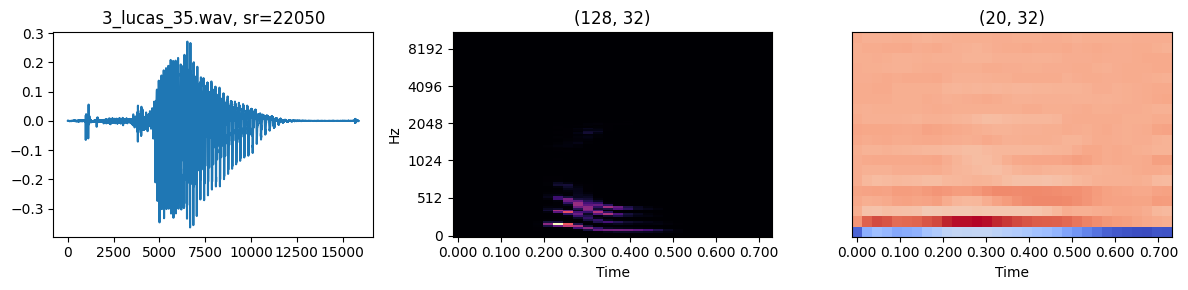

data length: 7586, sampling rate: 22050


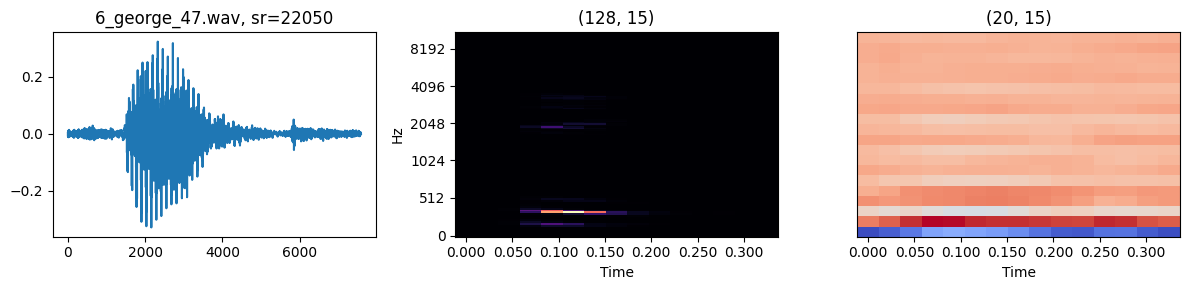

data length: 12244, sampling rate: 22050


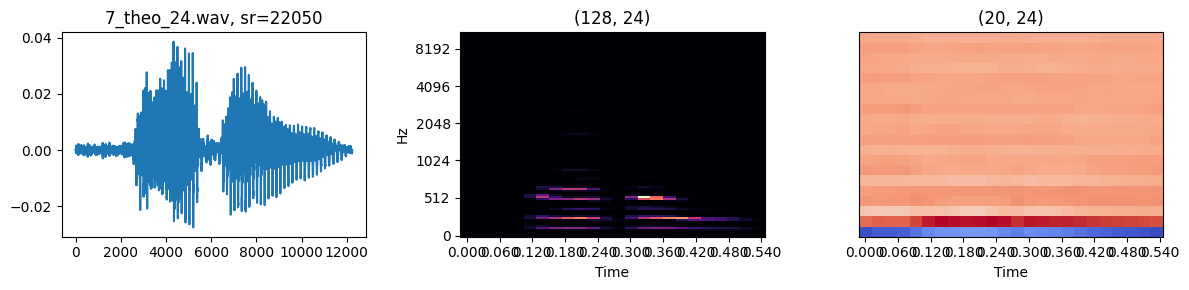

data length: 11323, sampling rate: 22050


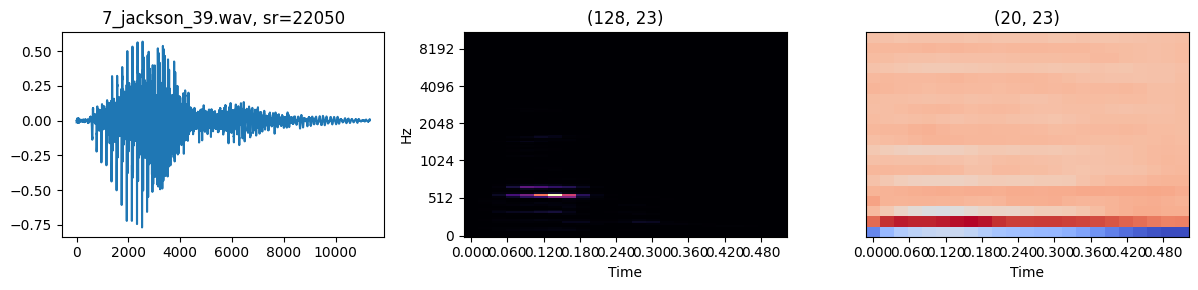

data length: 5935, sampling rate: 22050


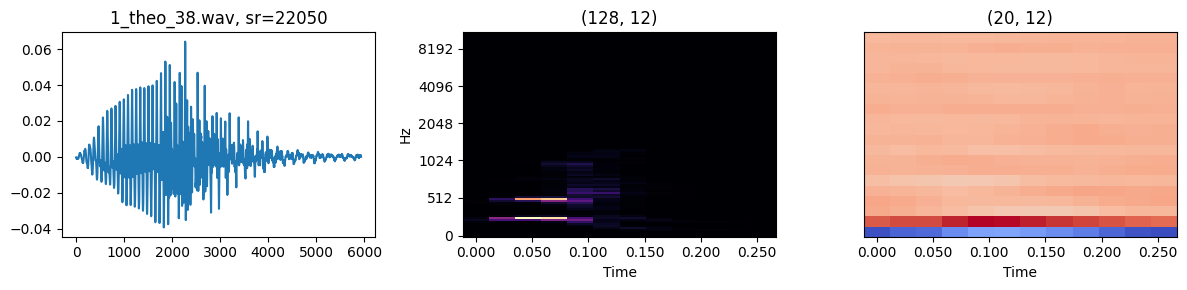

data length: 9261, sampling rate: 22050


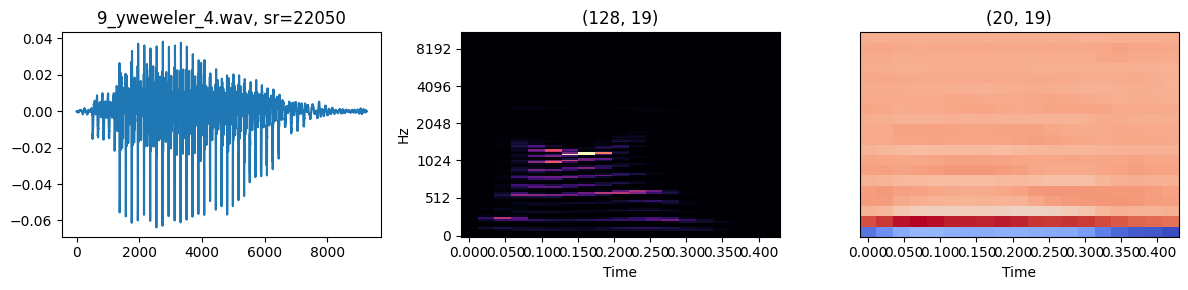

data length: 9964, sampling rate: 22050


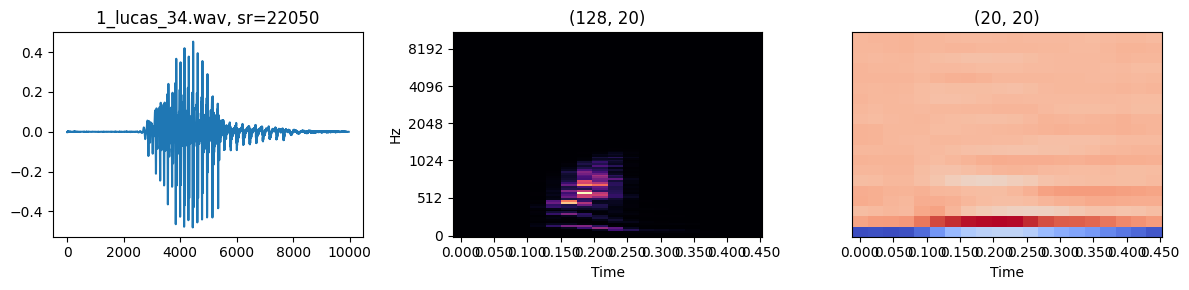

data length: 9468, sampling rate: 22050


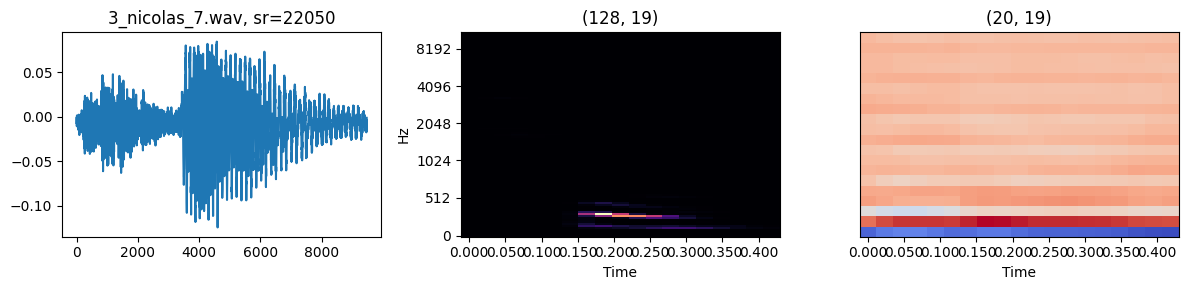

data length: 9402, sampling rate: 22050


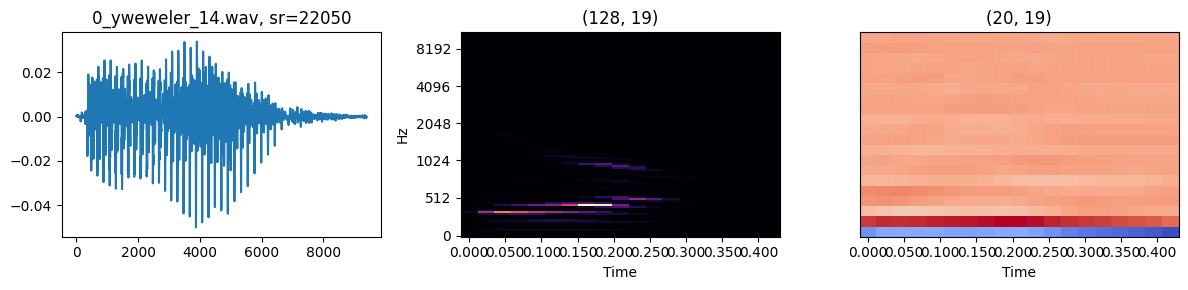

data length: 7158, sampling rate: 22050


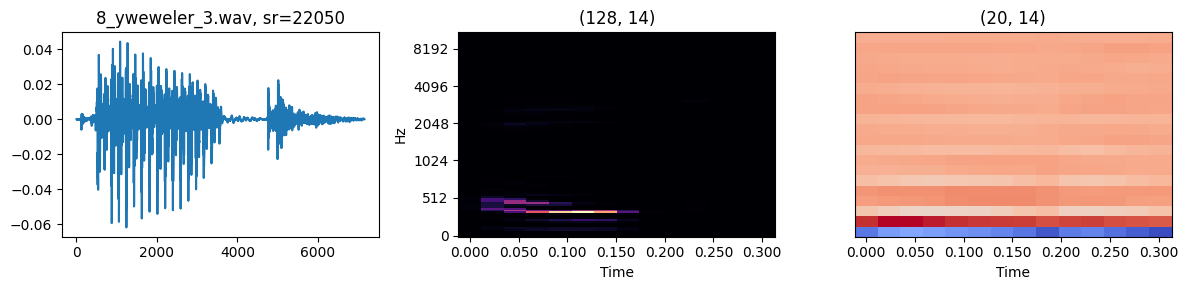

In [3]:
def wav_info(file):
    data,sr = librosa.load(file)
    print(f"data length: {len(data)}, sampling rate: {sr}")
    ipd.display(ipd.Audio(data, rate=sr))

    fig,ax = plt.subplots(1,3,figsize=(12,3))
    ax[0].plot(data)
    ax[0].set_title(f"{file.split('/')[-1]}, sr={sr}")

    mel = librosa.feature.melspectrogram(y=data, sr=sr)
    librosa.display.specshow(mel, x_axis='time', y_axis='mel', ax=ax[1])
    ax[1].set_title(f"{mel.shape}")

    mfcc = librosa.feature.mfcc(y=data, sr=sr)
    librosa.display.specshow(mfcc, x_axis='time', ax=ax[2])
    ax[2].set_title(f"{mfcc.shape}")
    plt.tight_layout()
    plt.show()

# 3000개 데이터에서 랜덤으로 10개 뽑기
num = np.random.randint(0,3000,10)
for file in np.array(files)[num]:
    wav_info(file)


# 3. EDA

In [4]:
data_len_list = []

print("데이터 분석 중 (샘플 수 측정)...")
for f in tqdm(files):
    # 1. 데이터를 실제로 로드합니다.
    # sr=None으로 설정해야 원본 샘플링 레이트 그대로 읽어와 정확한 샘플 수가 나옵니다.
    # SR = 8000 Hz
    data, sr = librosa.load(f, sr=None)
    
    # 2. 데이터 배열의 길이(샘플 수)를 구합니다.
    sample_count = len(data)
    
    # [파일경로, 샘플수] 저장
    data_len_list.append([f, sample_count])

# 데이터프레임 생성
df = pd.DataFrame(data_len_list, columns=['file', 'len'])

print(f"총 데이터 개수: {len(df)}")
df.describe()

데이터 분석 중 (샘플 수 측정)...


100%|██████████| 3000/3000 [00:25<00:00, 118.59it/s]

총 데이터 개수: 3000


,len
count,3000.000000
mean,3499.474667
std,1181.144044
min,1148.000000
25%,2738.750000
50%,3358.500000
75%,4082.250000
max,18262.000000


In [5]:
# 최소 Length, 최대 length 데이터로 데이터 프레임 만들기
# df.len.argmin() -> "len이라는 컬럼(열) 안에 있는 수많은 데이터 중, 가장 작은 값을 가진 '행(Row)의 번호'를 추출한다."
df_diff = pd.DataFrame([df.iloc[df.len.argmin()],df.iloc[df.len.argmax()]])
df_diff = df_diff.reset_index(drop=True)
df_diff

,file,len
0,/kaggle/input/datasets/joserzapata/free-spoken...,1148
1,/kaggle/input/datasets/joserzapata/free-spoken...,18262


data length: 3165, sampling rate: 22050


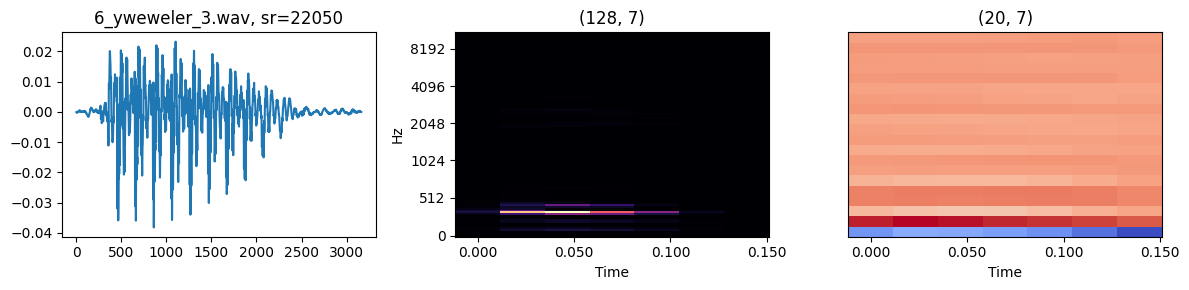

data length: 50335, sampling rate: 22050


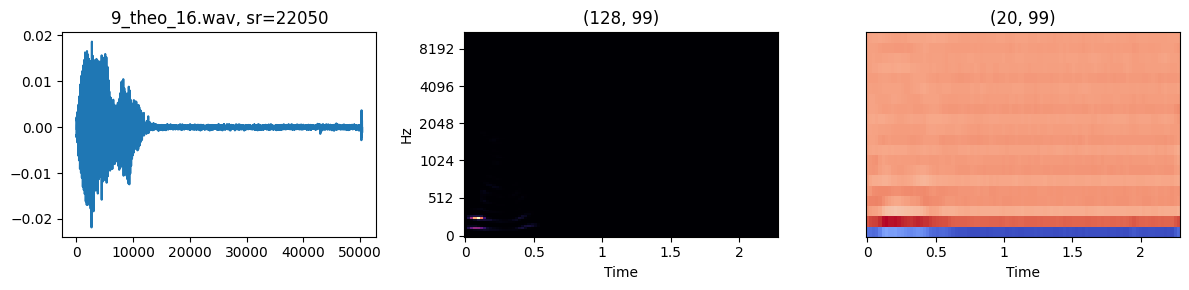

In [6]:
wav_info(df_diff.file[0])
wav_info(df_diff.file[1])
for file in df[df.len > 20000].file:
    wav_info(file)

In [7]:
print(f"현재 데이터 개수: {len(df)}")
print(f"인덱스 범위: {df.index.min()} ~ {df.index.max()}")

# [가정] 원본 데이터는 'data_orig', 전처리 후 데이터는 'data_pre' 변수에 있다고 가정합니다.
# 실제 사용 중인 변수명으로 바꿔서 입력해 보세요.

현재 데이터 개수: 3000
인덱스 범위: 0 ~ 2999


### 전처리 전: 3165, 50334
### 전처리 후: 1148, 18262


# 4. 데이터 전처리

data length: 28952, sampling rate: 22050
data length: 10000, [ 7168 12288]


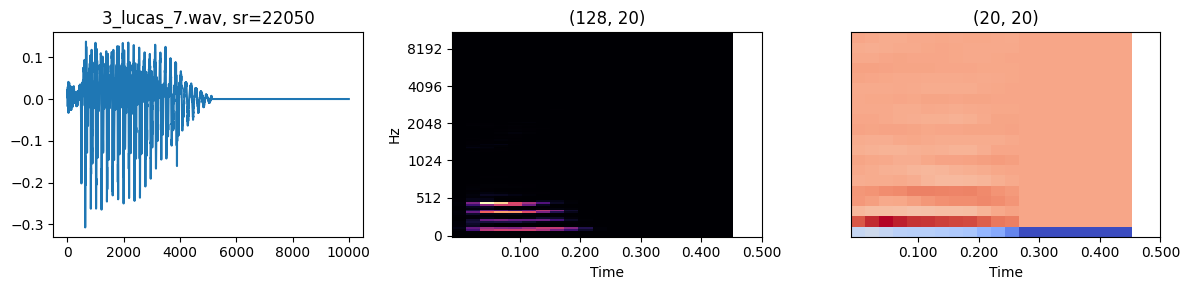

data length: 27825, sampling rate: 22050
data length: 10000, [5120 9728]


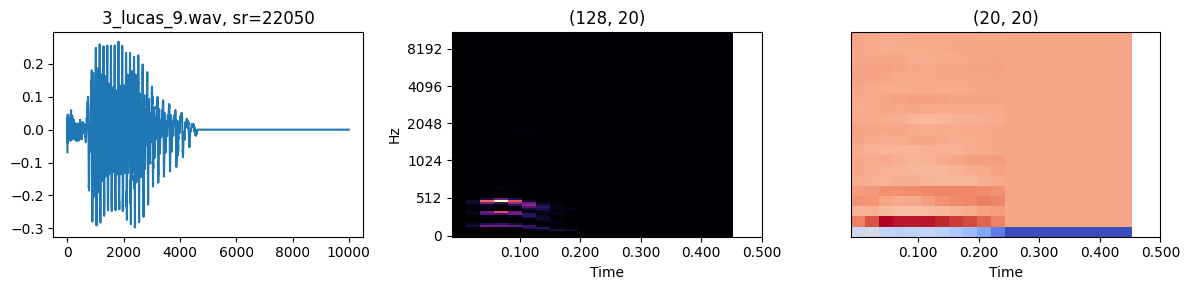

data length: 28663, sampling rate: 22050
data length: 10000, [2560 5632]


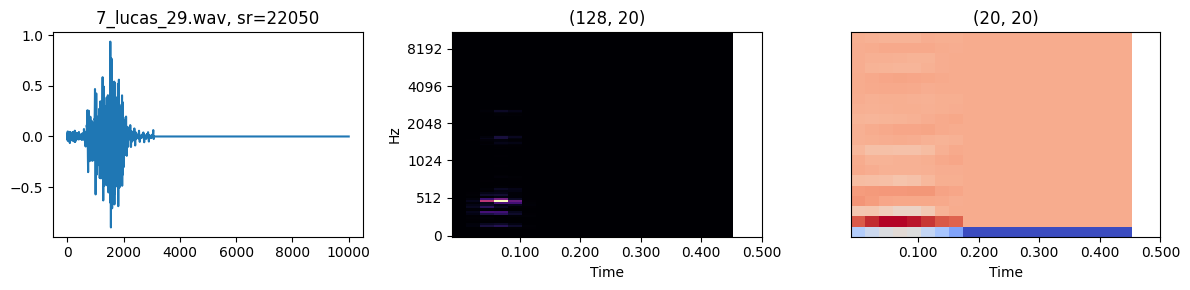

data length: 48420, sampling rate: 22050
data length: 10000, [2560 8704]


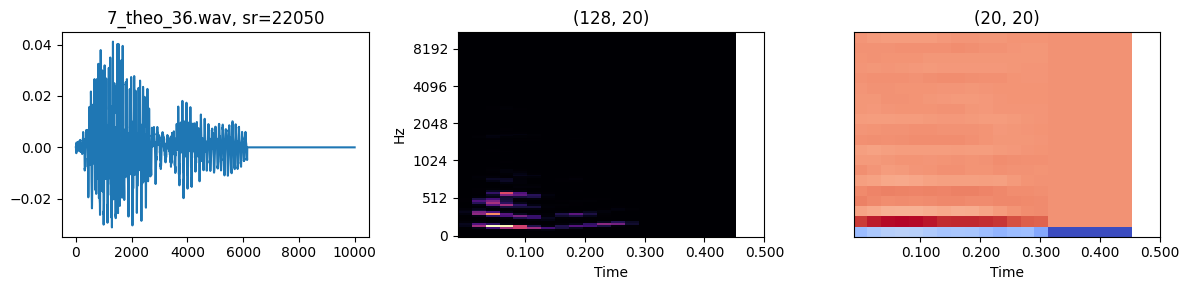

data length: 50335, sampling rate: 22050
data length: 10000, [    0 11264]


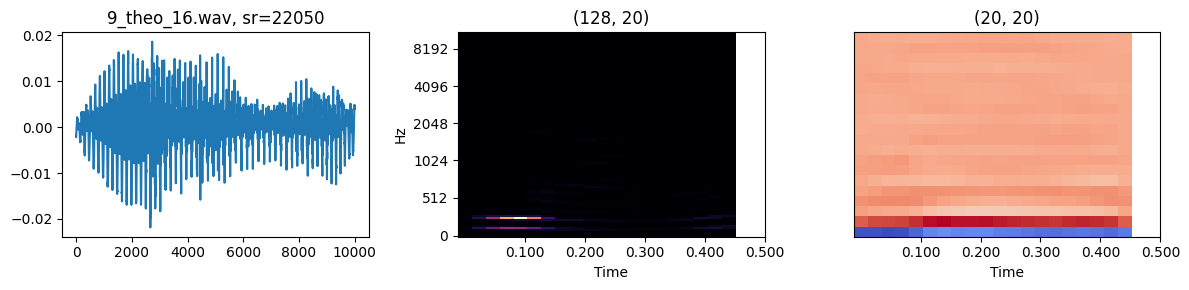

In [8]:
def wav_info(file, trim=False):
    data,sr = librosa.load(file)
    print(f"data length: {len(data)}, sampling rate: {sr}")
    if trim :
        data, area = librosa.effects.trim(data, top_db=10)
        data = librosa.util.fix_length(data, size=10000) # 전체 데이터 길이를 10000으로 맞춤. 실제 모델 분석 전
        print(f"data length: {len(data)}, {area}")

    ipd.display(ipd.Audio(data, rate=sr))

    fig,ax = plt.subplots(1,3,figsize=(12,3))
    ax[0].plot(data)
    ax[0].set_title(f"{file.split('/')[-1]}, sr={sr}")

    mel = librosa.feature.melspectrogram(y=data, sr=sr)
    librosa.display.specshow(mel, x_axis='time', y_axis='mel', ax=ax[1])
    ax[1].set_title(f"{mel.shape}")
    ax[1].set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])

    mfcc = librosa.feature.mfcc(y=data, sr=sr)
    librosa.display.specshow(mfcc, x_axis='time', ax=ax[2])
    ax[2].set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])    
    ax[2].set_title(f"{mfcc.shape}")

    plt.tight_layout() 
    plt.show()


for file in df[df.len > 10000].file: # 10000이상만 데이터 길이 10000으로
    wav_info(file, trim=True)
